**Mass-Spring-Damper (MSD) system implementation code in python**

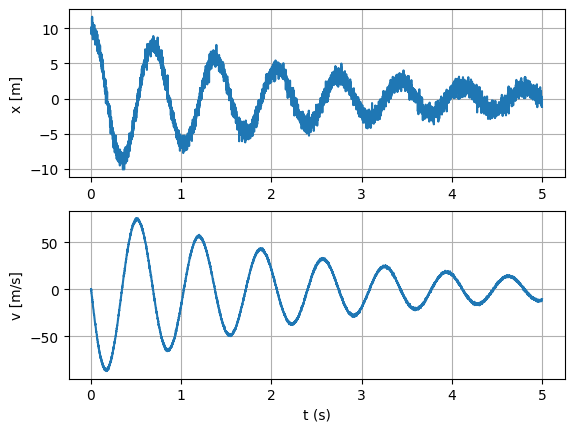

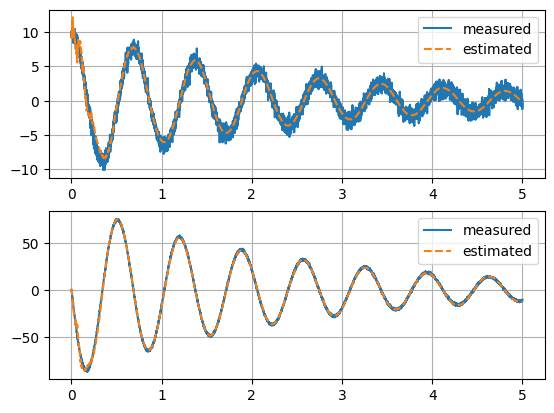

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel('DATAMSD.xlsx')
DATAMSD = df.values.T   # Transpose to match MATLAB format (2 × N)

# Simulation parameters
tf = 5
dt = 0.001
t = np.arange(dt, tf + dt, dt)

# Variables
n = 2
r = 10

# Initialization
x = np.array([[DATAMSD[0, 0]], [DATAMSD[1, 0]]])
xbar = x.copy()
thetabar = np.zeros((r, 1))

# Storage
xArray = []
xbarArray = []
thetabarArray = []

# Estimator parameters
lambdav = 0.995
lambdat = 0.999
Rx = np.eye(n)
Rt = np.eye(n)
Px = 0.1 * np.eye(n)
Pt = 0.1 * np.eye(r)
Gamma = np.zeros((n, r))

# Simulation loop
steps = int(tf/dt)

for i in range(steps):
    xArray.append(x.flatten())
    xbarArray.append(xbar.flatten())
    thetabarArray.append(thetabar.flatten())

    y = np.array([[DATAMSD[0, i]], [DATAMSD[1, i]]])

    Phi = np.array([
        [y[0, 0], y[1, 0], y[0, 0]**2, y[1, 0]**2, y[0, 0]*y[1, 0], 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, y[0, 0], y[1, 0], y[0, 0]**2, y[1, 0]**2, y[0, 0]*y[1, 0]]
    ])

    Kx = Px @ np.linalg.inv(Px + Rx)
    Kt = Pt @ Gamma.T @ np.linalg.inv(Gamma @ Pt @ Gamma.T + Rt)
    Gamma = (np.eye(n) - Kx) @ Gamma

    xbar = xbar + (Kx + Gamma @ Kt) @ (y - xbar)
    thetabar = thetabar - Kt @ (y - xbar)

    xbar = xbar + Phi @ thetabar

    Px = (1/lambdav) * (np.eye(n) - Kx) @ Px
    Pt = (1/lambdat) * (np.eye(r) - Kt @ Gamma) @ Pt
    Gamma = Gamma - Phi

# Convert lists to arrays
xArray = np.array(xArray).T
xbarArray = np.array(xbarArray).T
thetabarArray = np.array(thetabarArray).T

# Plot results
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(t, DATAMSD[0, :])
plt.grid()
plt.ylabel('x [m]')

plt.subplot(2, 1, 2)
plt.plot(t, DATAMSD[1, :])
plt.grid()
plt.ylabel('v [m/s]')
plt.xlabel('t (s)')

plt.figure()
plt.subplot(2, 1, 1)
plt.plot(t, DATAMSD[0, :], label='measured')
plt.plot(t, xbarArray[0, :], '--', label='estimated')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, DATAMSD[1, :], label='measured')
plt.plot(t, xbarArray[1, :], '--', label='estimated')
plt.legend()
plt.grid()

plt.show()
